In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

In [2]:
def SIR(t, y, beta, gamma):
  S = y[0]
  I = y[1]
  R = y[2]
  dSdt = -beta * S * I
  dIdt = beta * S * I - gamma * I
  dRdt = gamma * I
  return np.array([dSdt, dIdt, dRdt])

In [3]:
def rk4(f, y0, t, beta, gamma):
  n = len(t)
  y0 = np.array(y0)
  y = np.zeros((n, len(y0)))
  y[0] = y0

  for i in range(n-1):
    h = t[i+1] - t[i]

    k1 = np.array(f(t[i], y[i], beta, gamma))
    k2 = np.array(f(t[i] + h/2, y[i] + h*k1/2, beta, gamma))
    k3 = np.array(f(t[i] + h/2, y[i] + h*k2/2, beta, gamma))
    k4 = np.array(f(t[i] + h, y[i] + h*k3, beta, gamma))

    y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

  return y

In [4]:
class sir_nn(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(1, 32),
        nn.Tanh(),
        nn.Linear(32, 32),
        nn.Tanh(),
        nn.Linear(32, 32),
        nn.Tanh(),
        nn.Linear(32, 3),
    )

    self.beta = nn.Parameter(torch.tensor([0.5]))
    self.gamma = nn.Parameter(torch.tensor([0.5]))

  def forward(self, t):
    return nn.Softplus()(self.net(t))

In [5]:
# Derivar

def derivar(y, t):
  return torch.autograd.grad(y, t, grad_outputs= torch.ones_like(y), create_graph= True, retain_graph= True)[0]

# Losses
def loss_ic(model, y_0):
  m_0 = model(torch.tensor([0.0]))
  y_0_t = torch.tensor(y_0)

  return torch.mean((m_0[:3] - y_0_t)**2)

def loss_edo(model, t):
  tmp = model(t)
  s = tmp[:, 0:1]
  i = tmp[:, 1:2]
  r = tmp[:, 2:3]
  beta = model.beta
  gamma = model.gamma

  ds_dt = derivar(s, t)
  di_dt = derivar(i, t)
  dr_dt = derivar(r, t)

  diff_s = ds_dt + beta * s * i
  diff_i = di_dt - beta * s * i + gamma * i
  diff_r = dr_dt -  gamma * i

  return torch.mean(diff_s**2 + diff_i**2 + diff_r**2)

def loss_data(model, t, id_h_points, sol):
  t_h = t[id_h_points]

  model_h = model(t_h)
  sol_h = torch.tensor(sol[id_h_points])

  # Tensor's
  return torch.mean((sol_h - model_h[:, 0:3])**2)

def loss_sum_1(model, t):
  tmp = model(t)

  S = tmp[:, 0:1] 
  I   = tmp[:, 1:2]
  R = tmp[:, 2:3]

  return torch.mean((S + I + R - 1.0)**2)

In [6]:
# Timeline
t_start = 0.0
t_end = 40.0
n_points = 2000
t_real = torch.linspace(t_start, t_end, n_points).reshape(-1, 1)
t_real.requires_grad = True


#Helper points
h_points = []
id_h_points = []

########
n_helper_points = 8
########

id_h_points = np.linspace(0, n_points - 1, n_helper_points, dtype = int)
h_points = t_real[id_h_points].detach().numpy()


#print (id_h_points)
#print (h_points)

# Initial conditions
s_0, i_0, r_0 = 0.95, 0.05, 0.0
y_0 = np.array([s_0, i_0, r_0])


# N Epocas
n_ephocs = 10000


# Beta & gamma
beta = 0.8
gamma = 0.05


# Real RK4 Solution
sol = rk4(SIR, y_0, t_real.detach().numpy(), beta, gamma);

#####
#### MODELO PYTORCH
#####

# Learning Rate
lr = 1e-3


# Ruido
noise_level = 0.10
sol_noisy = sol.copy()

noise_levels = [1.0, 1.0, 1.0] # S, I, R
for k in range(3):  # S, I, R
  std = noise_level * noise_levels[k] * np.max(sol[:, k])
  sol_noisy[:, k] += np.random.normal(0.0, std, size=sol.shape[0])
  sol_noisy[:, k]  = np.abs(sol_noisy[:, k])
  sol_noisy = np.clip(sol_noisy, 0.0, 1.0)

# Collocation points
n_collocation = 2000
indices = torch.randperm(t_real.shape[0])[:n_collocation]
t_colloc = t_real[indices].clone().detach()
t_colloc.requires_grad = True

In [7]:
# Get grads
def get_grad_data(loss, model):
  net_params = list(model.net.parameters())  # ← Solo la red
    
  grads = torch.autograd.grad(loss,
                              net_params,
                              retain_graph=True,
                              create_graph=False)

  t_median = 0.0
  t_max = 0.0

  counter = 0
  
  for grad in grads:
    if (grad is None):
      continue
      
    counter += 1
    t_median += grad.abs().mean().item();
    if (t_max < grad.abs().max().item()):
      t_max = grad.abs().max().item()

  t_median /= counter
  return t_median, t_max
  
t_median, t_max = get_grad_data(loss_ic(model, y_0), model)

print("t_median: ", t_median)
print("t_max: ", t_max)


t_median:  0.025702544255182147
t_max:  0.20372417569160461


In [8]:
# Simulacion NN
def train():
  model = sir_nn()  
  # Optimizer
  optimizer = optim.Adam(model.parameters(), lr)
  
  recalcularEphocs = 1
  
  ic_weight = 1
  data_weight = 1
  sum_weight = 1
  edo_weight = 1.6
  
  alpha = 0.75
  
  startTime = time.perf_counter()
  for epoch in range(n_ephocs):
  
    '''
    if (epoch % recalcularEphocs == 0):
      ic_median, max_median = get_grad_data(loss_ic(model, y_0), model)
      edo_median, max_edo = get_grad_data(loss_edo(model, t_colloc), model)
      data_median, max_data = get_grad_data(loss_data(model, t_real, id_h_points, sol_noisy), model)
      sum_median, max_sum = get_grad_data(loss_sum_1(model, t_colloc), model)
  
      ic_new = max_edo / ic_median
      data_new = max_edo / data_median
      sum_new = max_edo / sum_median
      
      ic_weight = (1 - alpha)*ic_weight + alpha * ic_new
      data_weight = ((1 - alpha)*data_weight + alpha * data_new ) * 0.5
      sum_weight = (1 - alpha)*sum_weight + alpha * sum_new
      
    loss = ic_weight*loss_ic(model, y_0) + edo_weight * loss_edo(model, t_colloc) + data_weight * loss_data(model, t_real, id_h_points, sol_noisy) + sum_weight * loss_sum_1(model, t_colloc)
    '''
    
    loss = 10*loss_ic(model, y_0) + 40*loss_edo(model, t_colloc) + loss_data(model, t_real, id_h_points, sol_noisy) + loss_sum_1(model, t_colloc)
    #loss = loss_ic(model, y_0) + loss_edo(model, t_colloc) + loss_data(model, t_real, id_h_points, sol_noisy) + loss_sum_1(model, t_colloc)
  
    if (epoch % 500 == 0):
      print(epoch)
  
  
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    
  endTime = time.perf_counter()
  return model

In [9]:
model = train()

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500


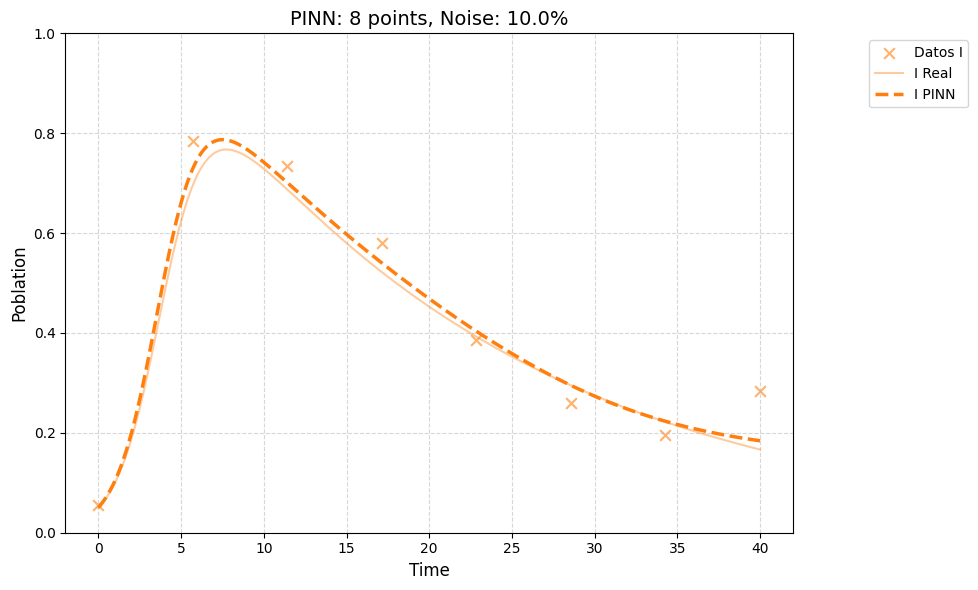

In [ ]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['S', 'I', 'R']

plt.figure(figsize=(10, 6))

#plt.scatter(h_points, sol_noisy[id_h_points, 0], color=colors[0], marker='x', s=60, label="Datos S", alpha=0.6)
plt.scatter(h_points, sol_noisy[id_h_points, 1], color=colors[1], marker='x', s=60, label="Datos I", alpha=0.6)
#plt.scatter(h_points, sol_noisy[id_h_points, 2], color=colors[2], marker='x', s=60, label="Datos R", alpha=0.6)

# REAL
t_plot = t_real.detach().numpy()
plt.plot(t_plot, sol[:, 1], color=colors[1], linestyle='-', linewidth=1.5, alpha=0.4, label=f"{labels[1]} Real")


# PINNs
model_sol = model(t_real).detach().numpy()
plt.plot(t_plot, model_sol[:, 1], color=colors[1], linestyle='--', linewidth=2.5, label=f"{labels[1]} PINN")


plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Poblation', fontsize=12)
plt.title(f"PINN: {n_helper_points} points, Noise: {noise_level*100}%", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.ylim(0.0, 1.0)

plt.show()

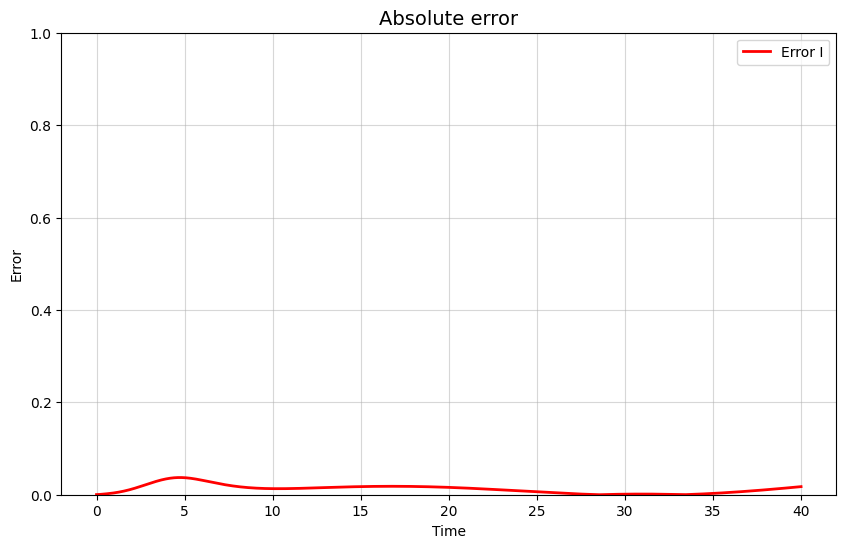

In [24]:
sol_np = sol
model_np = model_sol

# Calculamos error absoluto
error_s = np.abs(sol_np[:, 0] - model_np[:, 0])
error_i = np.abs(sol_np[:, 1] - model_np[:, 1])
error_r = np.abs(sol_np[:, 2] - model_np[:, 2])

plt.figure(figsize=(10,6))
#plt.plot(t_plot, error_s, label="Error S", color='blue', linewidth=2)
plt.plot(t_plot, error_i, label="Error I", color='red', linewidth=2)
#plt.plot(t_plot, error_r, label="Error R", color='green', linewidth=2)

plt.xlabel("Time")
plt.ylabel("Error")
plt.title(f"Absolute error", fontsize=14)
plt.legend()
plt.grid(alpha=0.5)
plt.ylim(0.0, 1.0)

plt.show()

In [21]:
data = {
    "Variable": ["S", "I", "R"],
    "Mean Error": [
      np.mean(error_s),
      np.mean(error_i),
      np.mean(error_r)
    ],
    "Max error": [
      np.max(error_s),
      np.max(error_i),
      np.max(error_r)
    ],
    "RMSE": [
      np.sqrt(np.mean(error_s**2)),
      np.sqrt(np.mean(error_i**2)),
      np.sqrt(np.mean(error_r**2))
    ]
}

df_error = pd.DataFrame(data)
print(df_error)

#totalTime = endTime - startTime
#print(f"Tiempo en total: {totalTime:.2f} segundos")

  Variable  Mean Error  Max error      RMSE
0        S    0.006241   0.030937  0.009537
1        I    0.012249   0.037209  0.015354
2        R    0.008842   0.026257  0.012107


In [22]:
# Parameters
print(f"Beta: {model.beta.item()}")
print(f"Gamma: {model.gamma.item()}")

print("\n\nError: ")
print(f"Relative Beta error: {np.abs(model.beta.item()/beta * 100 - 100)}")
print(f"Relative Gamma error: {np.abs(model.gamma.item()/gamma * 100 - 100)}")

Beta: 0.823052704334259
Gamma: 0.04877400025725365


Error: 
Relative Beta error: 2.881588041782379
Relative Gamma error: 2.4519994854927063
